# EDA dan Checking

Library dan import data

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv('Churn_Modelling.csv')

Data Checking

In [5]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

Jumlah Baris dan Kolom:
(10000, 14)

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [ ]:
missing = df.isnull().sum()

missing

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [8]:
print("Jumlah Duplikasi :", df.duplicated().sum())

Jumlah Duplikasi : 0


Deskripsi data

In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


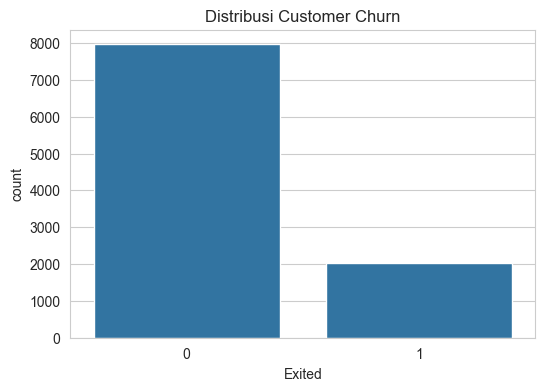

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [53]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Exited'
)

plt.title("Distribusi Customer Churn")
plt.show()

print(df['Exited'].value_counts(normalize=True)*100)

Distribusi normal

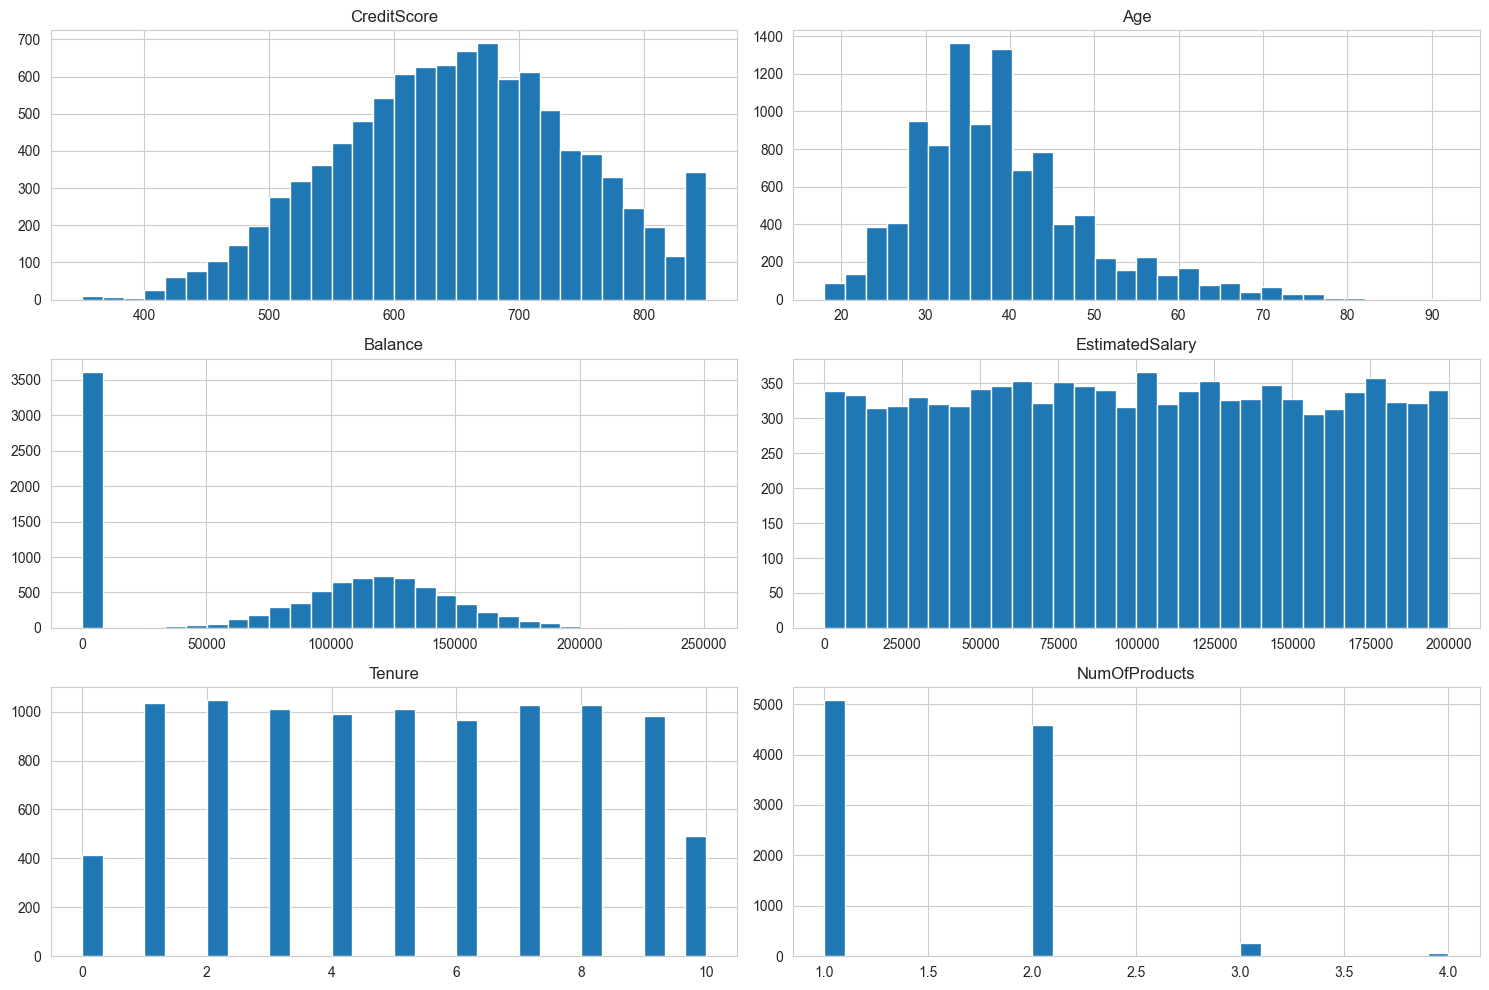

In [55]:
num_cols = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary',
    'Tenure',
    'NumOfProducts'
]

df[num_cols].hist(
    bins=30,
    figsize=(15,10)
)

plt.tight_layout()
plt.show()

Boxplot

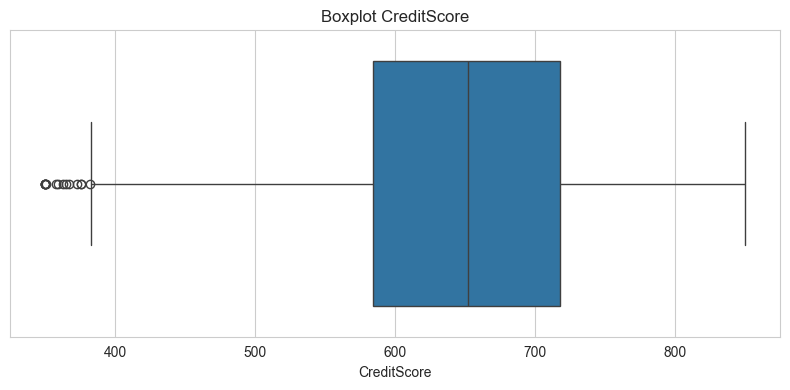

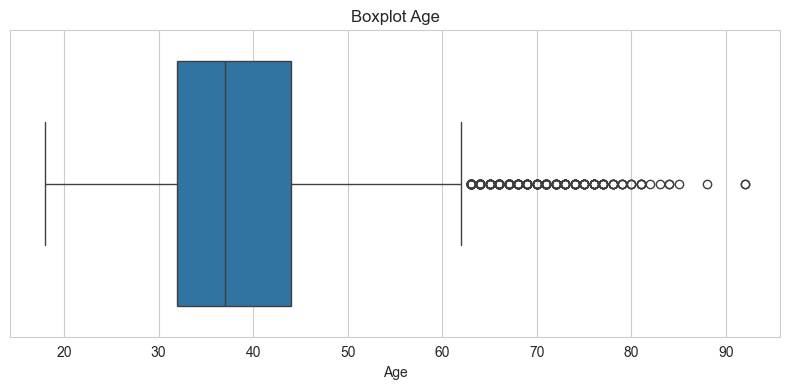

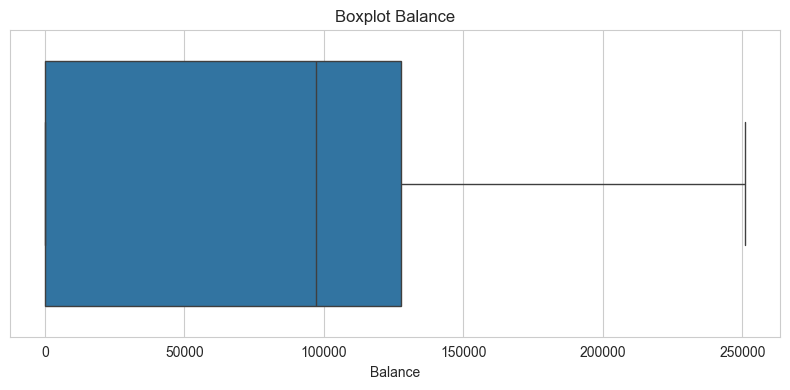

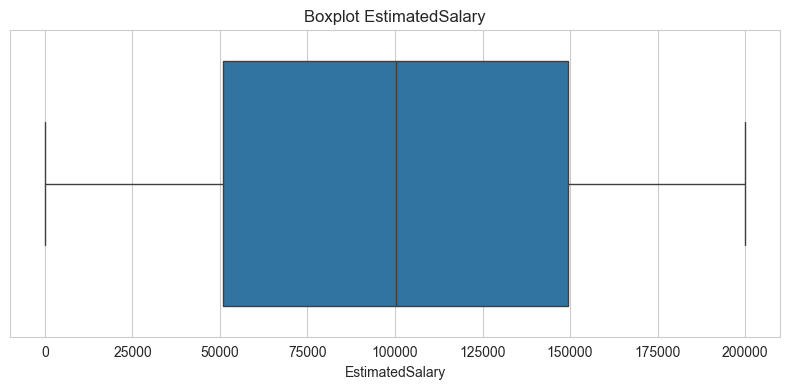

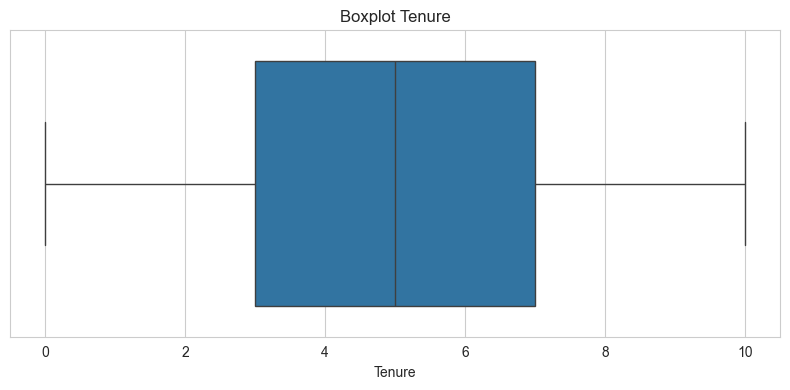

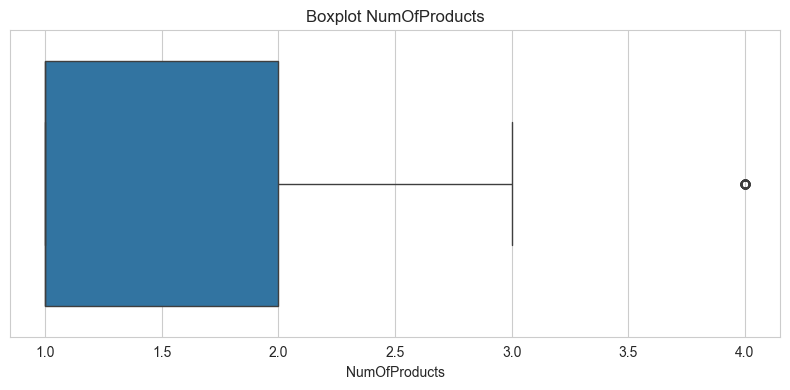

In [ ]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f"Boxplot {col}")
    plt.show()

# Analisis Univariat

## Gender & Churn

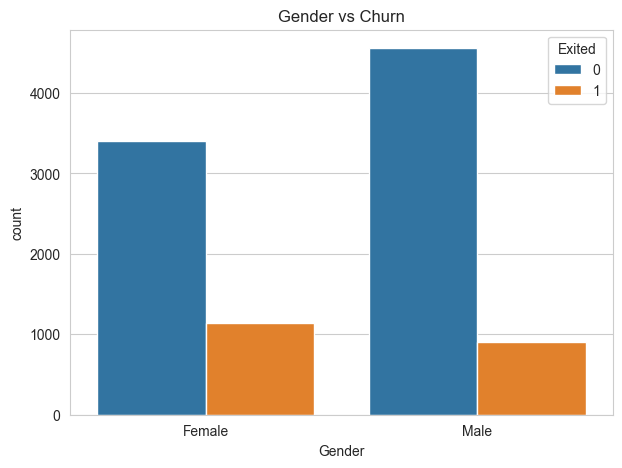

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Exited'
)

plt.title("Gender vs Churn")
plt.show()

## Churn & Geography

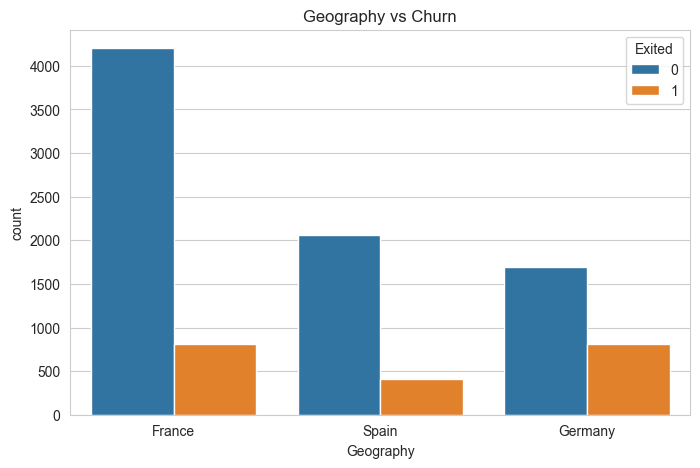

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Geography',
    hue='Exited'
)

plt.title("Geography vs Churn")
plt.show()

## Churn rate per Country

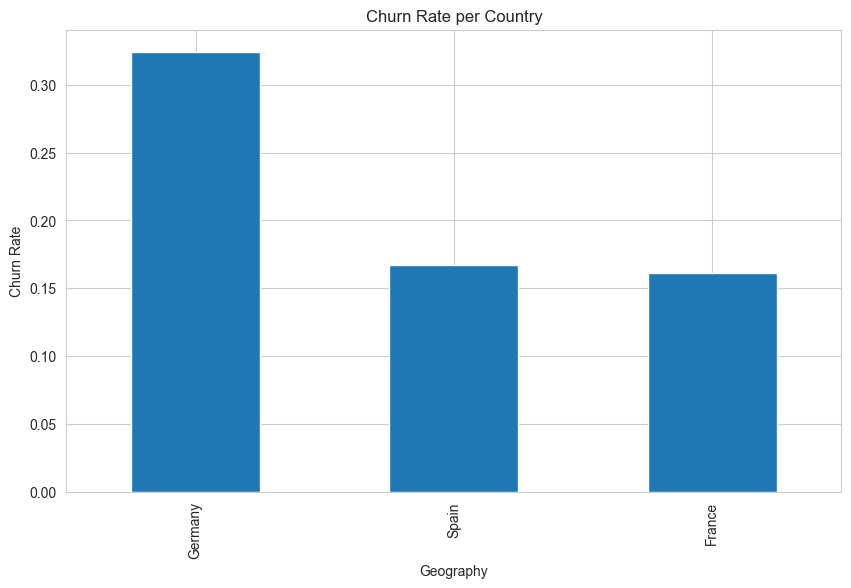

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

In [18]:
country_churn = (
    df.groupby('Geography')['Exited']
    .mean()
    .sort_values(ascending=False)
)

country_churn.plot(
    kind='bar'
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate per Country")
plt.show()

country_churn

## Churn Rate Semua Kategori

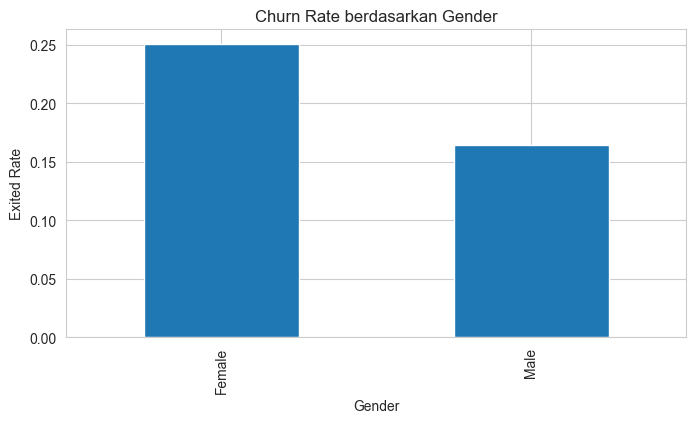

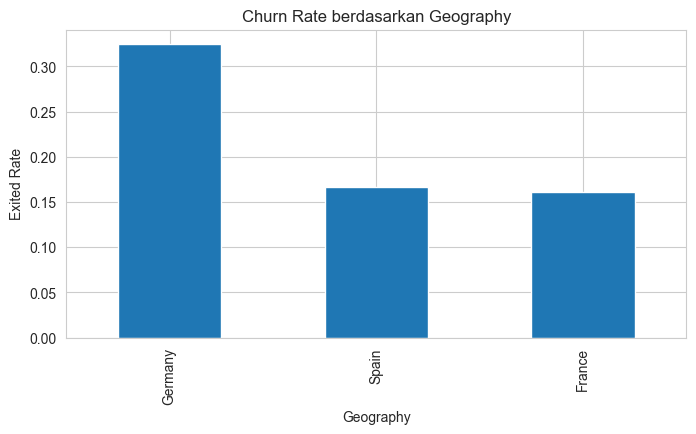

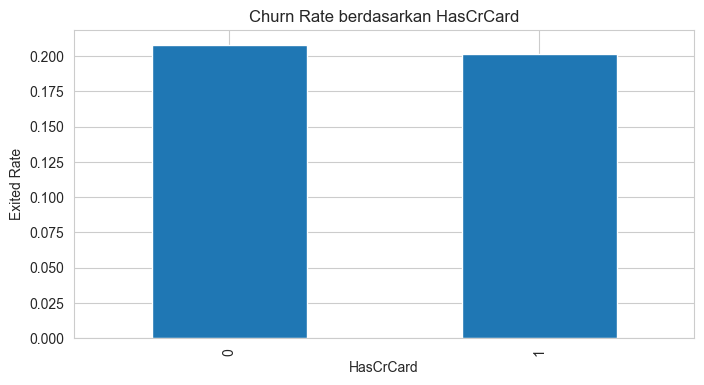

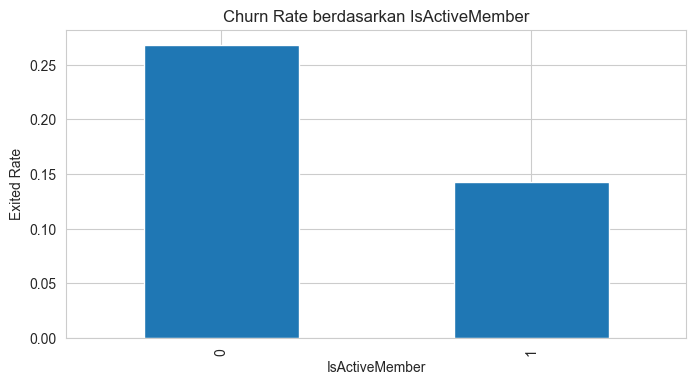

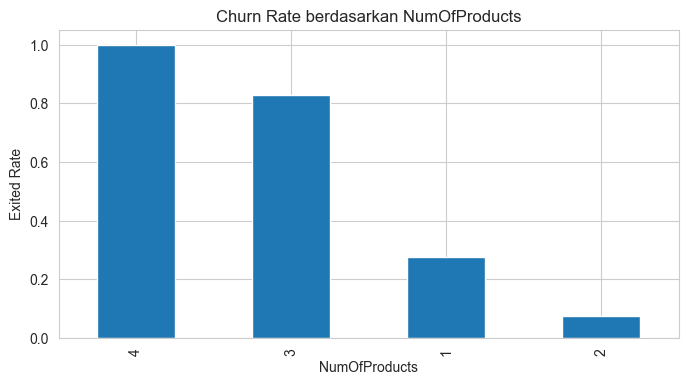

In [22]:
cat_cols = [
    'Gender',
    'Geography',
    'HasCrCard',
    'IsActiveMember',
    'NumOfProducts'
]

for col in cat_cols:
    
    churn_rate = (
        df.groupby(col)['Exited']
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8,4))

    churn_rate.plot(
        kind='bar'
    )

    plt.title(f"Churn Rate berdasarkan {col}")
    plt.ylabel("Exited Rate")
    plt.show()

# Analisis per Regional

In [23]:
country_count = (
    df['Geography']
    .value_counts()
    .reset_index()
)

country_count.columns = [
    'country',
    'customers'
]

country_count

,country,customers
0,France,5014
1,Germany,2509
2,Spain,2477


In [26]:
import plotly.express as px

country_count = (
    df['Geography']
    .value_counts()
    .reset_index()
)

country_count.columns = [
    'country',
    'customers'
]

fig = px.choropleth(
    country_count,
    locations='country',
    locationmode='country names',
    color='customers',
    color_continuous_scale='Blues',
    title='Jumlah Customer per Negara'
)

fig.show()

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_18864\913953995.py:14: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [47]:
import plotly.express as px

churn_country = (
    df[df['Exited'] == 1]
    .groupby('Geography')
    .size()
    .reset_index(name='churn_customers')
)

churn_country.columns = [
    'country',
    'churn_customers'
]

fig = px.choropleth(
    churn_country,
    locations='country',
    locationmode='country names',
    color='churn_customers',
    color_continuous_scale='Reds',
    title='Jumlah Customer Churn per Negara'
)

fig.show()

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_18864\81698842.py:15: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [48]:
non_churn_country = (
    df[df['Exited'] == 0]
    .groupby('Geography')
    .size()
    .reset_index(name='active_customers')
)

non_churn_country.columns = [
    'country',
    'active_customers'
]

fig = px.choropleth(
    non_churn_country,
    locations='country',
    locationmode='country names',
    color='active_customers',
    color_continuous_scale='Greens',
    title='Jumlah Customer Tidak Churn per Negara'
)

fig.show()

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_18864\1928944602.py:13: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [49]:
country_status = (
    df.groupby(['Geography', 'Exited'])
    .size()
    .reset_index(name='customers')
)

country_status['Status'] = country_status['Exited'].map({
    0: 'Tidak Churn',
    1: 'Churn'
})

country_status.columns = [
    'country',
    'Exited',
    'customers',
    'Status'
]

fig = px.choropleth(
    country_status,
    locations='country',
    locationmode='country names',
    color='customers',
    animation_frame='Status',
    color_continuous_scale='Viridis',
    title='Distribusi Customer Churn dan Tidak Churn per Negara'
)

fig.show()

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_18864\2654156670.py:19: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [28]:
country_churn = (
    df.groupby('Geography')['Exited']
    .mean()
    .reset_index()
)

country_churn.columns = [
    'country',
    'churn_rate'
]

fig = px.choropleth(
    country_churn,
    locations='country',
    locationmode='country names',
    color='churn_rate',
    color_continuous_scale='Reds',
    title='Churn Rate per Negara'
)

fig.show()

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_18864\2903059348.py:12: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
